In [2]:
import numpy as np

# Semilla para que los datos sean reproducibles.
rng = np.random.default_rng(42)

n_por_clase = 100
ruido = 0.08
angulos = rng.uniform(0, 2 * np.pi, size=2 * n_por_clase)

# Dos circunferencias concentricas: clase 0 interna y clase 1 externa.
radios = np.concatenate((
    np.full(n_por_clase, 1.0),
    np.full(n_por_clase, 2.0),
))
x0 = radios * np.cos(angulos) + rng.normal(0, ruido, size=2 * n_por_clase)
x1 = radios * np.sin(angulos) + rng.normal(0, ruido, size=2 * n_por_clase)
y = np.concatenate((
    np.zeros(n_por_clase, dtype=int),
    np.ones(n_por_clase, dtype=int),
))

X = np.column_stack((x0, x1))

print(f"Forma de X: {X.shape}")
print(f"Distribucion de etiquetas: {np.bincount(y)}")
print(f"Ruido aplicado: desviacion estandar {ruido}")

Forma de X: (200, 2)
Distribucion de etiquetas: [100 100]
Ruido aplicado: desviacion estandar 0.08


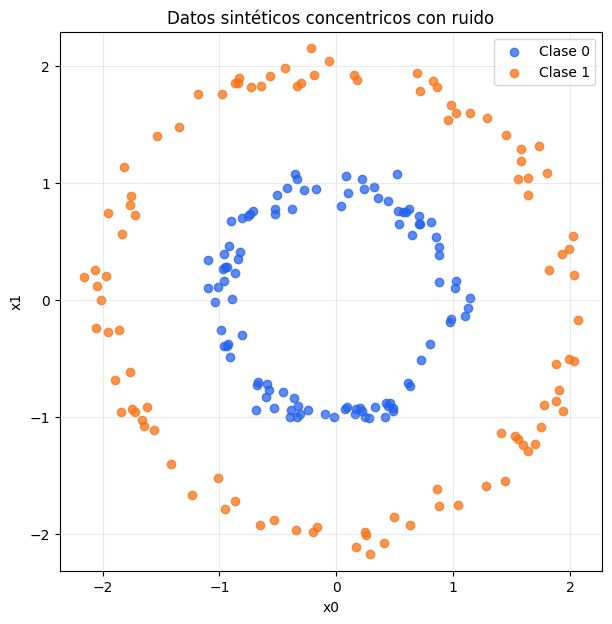

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(x0[y == 0], x1[y == 0], label="Clase 0", alpha=0.75, color="#2563eb")
plt.scatter(x0[y == 1], x1[y == 1], label="Clase 1", alpha=0.75, color="#f97316")
plt.title("Datos sintéticos concentricos con ruido")
plt.xlabel("x0")
plt.ylabel("x1")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.20.0


In [5]:
!python --version

Python 3.13.15


In [6]:
!nvidia-smi

Wed Aug 26 16:15:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
#Declarar una red neuronal con cuatro capas, 16,8,4 y la salida. En la forma A


prueba = models.Sequential([
    layers.Input(shape=(2,)),              # Capa de entrada 
    layers.Dense(16, activation='relu'),   # Capa oculta 1 
    layers.Dense(8, activation='relu'),   # Capa oculta 2 
    layers.Dense(4, activation='relu'),   # Capa oculta 3 
    layers.Dense(1, activation='sigmoid')  # Capa de salida
])

prueba.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
prueba.compile(
    optimizer=optimizers.Adam(learning_rate=0.03),
    loss="mean_squared_error",
    metrics=["accuracy"],
)

'''y_entrenamiento = y.reshape(-1, 1)
historial = prueba.fit(
    X,
    y_entrenamiento,
    epochs=100,
    batch_size=16,
    verbose=0,
)

print(f"Perdida final (binary cross entropy): {historial.history['loss'][-1]:.4f}")
print(f"MSE final: {historial.history['mse'][-1]:.4f}")
print(f"Binary cross entropy final: {historial.history['binary_crossentropy'][-1]:.4f}")'''

prueba.summary()

#Entrenar
history = prueba.fit(X,y, epochs=100, verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 1.0000 - loss: 1.2873e-12
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.2873e-12 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.2871e-12 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.2870e-12 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.2869e-12 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.2868e-12 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.2866e-12 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.2863e-12 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.2859e-12 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.2856e-12 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 1.2853e-12 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 

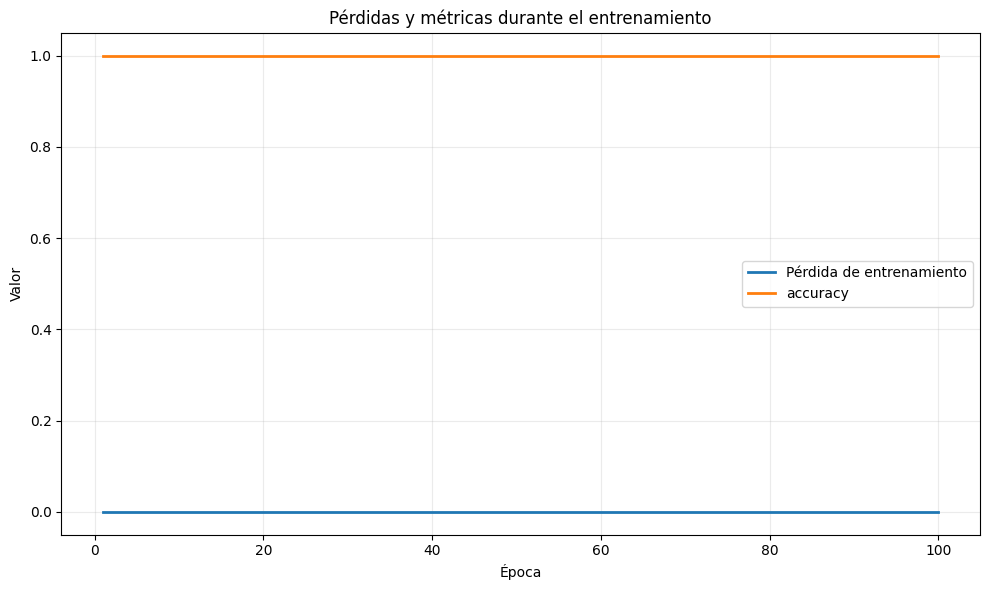

In [19]:
import matplotlib.pyplot as plt

historial_metricas = history.history
epocas = range(1, len(historial_metricas["loss"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epocas, historial_metricas["loss"], label="Pérdida de entrenamiento", linewidth=2)

for nombre, valores in historial_metricas.items():
    if nombre != "loss":
        plt.plot(epocas, valores, label=nombre, linewidth=2)

plt.title("Pérdidas y métricas durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
import joblib

archivo_modelo = "modelo_prueba_joblib.joblib"
modelo_persistido = {
    "arquitectura": prueba.get_config(),
    "pesos": prueba.get_weights(),
}
joblib.dump(modelo_persistido, archivo_modelo)

print(f"Modelo persistido en: {archivo_modelo}")
print(f"Numero de matrices de pesos: {len(modelo_persistido['pesos'])}")

Modelo persistido en: modelo_prueba_joblib.joblib
Numero de matrices de pesos: 8


In [21]:
type(prueba)

keras.src.models.sequential.Sequential

In [ ]:
prueba.save("modelo.keras")
